In [1]:
import pandas as pd
import numpy as np
from tslearn.clustering import TimeSeriesKMeans
import matplotlib.pyplot as plt
from utils import *
import math

In [2]:
df_1_hME1_scaled = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1_functional_names_diff_scaled_phPlus_localized.xlsx")
df_1_hME1_scaled = df_1_hME1_scaled.fillna(0)

df_2_hME1_scaled = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_functional_names_diff_scaled_phPlus.xlsx")
df_2_hME1_scaled = df_2_hME1_scaled.fillna(0)

df_1_HEK_scaled = pd.read_excel("Experiment/1_HEK293T/Data/Processed/Full_dataset_HEK293T_functional_names_diff_scaled_phPlus.xlsx")
df_1_HEK_scaled = df_1_HEK_scaled.fillna(0)

In [46]:
#FILTERING DATA
dataframe = df_1_HEK_scaled.copy()
######### Phospho site localization
# > 0 means localized site (at least one)
# = 0 means no localized
subdata = dataframe.loc[dataframe["localized_sites"] > 0]

######### Phospho site replicates
# > 1 means at least 2 reps
# > 2 means at least 3 reps
subdata = subdata.loc[subdata["n_rep"] > 1]

######### ERK motif
# 0 means no ERK motif
# 1 means yes ERK motif
subdata_erk_motif = subdata.loc[subdata["ERK_motif"] == 1]

######### functional score
subdata_f_score = subdata.loc[subdata["functional_score"] > 0.5]


combined = subdata_erk_motif.loc[subdata_erk_motif["functional_score"] > 0.5]
# ######### ms lit
# subdata_ms_lit = subdata.loc[subdata["ms_lit"] > 0.5]

In [48]:
print(f"Length of original dataframe = {len(dataframe)}")
# Filter based in profile parameter
subdata = subdata.copy()

print(f"len(subdata) [(localized_sites > 0) & (n_rep > 1)] = {len(subdata)}")
##################### FC threshold
data_type = "log2_FC"
exclude_full = False
condition_for_clustering = ["_EGF_"]
column_names = subdata.columns.tolist()
if len(condition_for_clustering) == 0:
    column_selection = [element for element in column_names if element.startswith(f"{data_type}")] #f"{data_type}" in element]
    if exclude_full == True:
        column_selection = [element for element in column_names if element.startswith(f"{data_type}") and "full" not in element]
else:
    column_selection = [element for element in column_names if element.startswith(f"{data_type}") and any(cond in element for cond in condition_for_clustering)]
    if exclude_full == True:
        column_selection = [element for element in column_names if element.startswith(f"{data_type}") and any(cond in element for cond in condition_for_clustering) and "full" not in element]


mask = subdata[column_selection].abs().max(axis=1) > 0.5
subdata_fc = subdata.loc[mask].copy()
print(f"len(subdata_fc) [FC >0.5] = {len(subdata_fc)}")

print(f"Clustering based on {column_selection}")
# data_type = "log2_FC" #
# column_names = subdata.columns.tolist()
# column_selection = [element for element in column_names if element.startswith(f"{data_type}") and "full" not in element]
#
# mask = subdata_fc[column_selection].abs().max(axis=1) > 0.3
# subdata_fc_2 = subdata_fc.loc[mask].copy()
# print(f"len(subdata_fc_2) [0.3 < FC < 0.5)]= {len(subdata_fc_2)}")
# subdata_fc
#################### PVALUE
# data_type = "FC_pvalue" #data type over which I want to do the filtering and the clustering
#
# column_names = subdata.columns.tolist()
# column_selection = [element for element in column_names if f"{data_type}" in element and "full" not in element and "starve" not in element]
# neglog10 = -np.log10(subdata[column_selection])
# mask = (neglog10 > 2).any(axis=1)
# # mask = subdata[column_selection].max(axis=1) > 0.05 #dont understand why i have to it this way
# subdata_pv = subdata.loc[mask].copy()
# print(len(subdata_pv))

Length of original dataframe = 36578
len(subdata) [(localized_sites > 0) & (n_rep > 1)] = 16391
len(subdata_fc) [FC >0.5] = 2927
Clustering based on ['log2_FC_EGF_full', 'log2_FC_EGF_starve', 'log2_FC_EGF_2', 'log2_FC_EGF_5', 'log2_FC_EGF_10', 'log2_FC_EGF_15', 'log2_FC_EGF_90']


In [49]:
def tslearn_clustering_KMeans(df_to_cluster,
                              data_type,
                              condition_for_clustering = list,
                              exclude_full = False,
                              cluster_column_name = str,
                              number_of_clusters = int,
                              max_iterations = 1000,
                              metric='euclidean',
                              df_dimensions = int,
                              time_series_length = int,
                              verbose = True ):

    column_names = df_to_cluster.columns.tolist()
    if len(condition_for_clustering) == 0:
        column_selection = [element for element in column_names if element.startswith(f"{data_type}")] #f"{data_type}" in element]
        if exclude_full == True:
         column_selection = [element for element in column_names if element.startswith(f"{data_type}") and "full" not in element]
    else:
        column_selection = [element for element in column_names if element.startswith(f"{data_type}") and any(cond in element for cond in condition_for_clustering)]
        if exclude_full == True:
            column_selection = [element for element in column_names if element.startswith(f"{data_type}") and any(cond in element for cond in condition_for_clustering) and "full" not in element]

    multivariate_df, names_of_myseries = reshape_df(df = df_to_cluster, time_series = column_selection, dimensions = df_dimensions, len_time_serie = time_series_length)
    print(f"\nThe size of the dataset is {multivariate_df.shape}")

    clustering = TimeSeriesKMeans(n_clusters=number_of_clusters, max_iter=max_iterations, metric=metric, max_iter_barycenter=1000, verbose=verbose, random_state=0).fit(multivariate_df)

    df_to_cluster[f"{cluster_column_name}"] = clustering.labels_

    return df_to_cluster

In [50]:
cluster_column_name = "testing" #[ERKmotif0]_  [Fscore>05]
data_to_cluster = subdata_fc.copy()

tslearn_clustering_KMeans(df_to_cluster = data_to_cluster,
                          data_type = "log2_FC",
                          condition_for_clustering = ["_EGF_"],
                          exclude_full = False,
                          cluster_column_name = cluster_column_name, #"DTW_log2_FC_locSize>0_nrep>1_5_KMeans_81clusters",
                          number_of_clusters = 25,
                          max_iterations = 500,
                          metric='dtw', # dtw, euclidean, softdtw
                          df_dimensions = 1,
                          time_series_length = 7,
                          verbose = False )
# #3400 sites -> 4 mins (1000 max iterations, 81 clusters

df_1_HEK_scaled = pd.merge(df_1_HEK_scaled, data_to_cluster[["site", f"{cluster_column_name}"]], on="site", how="left")

df_1_HEK_scaled = df_1_HEK_scaled.fillna(999)

df_1_HEK_scaled[f"{cluster_column_name}"] = df_1_HEK_scaled[f"{cluster_column_name}"].astype(int)
#
df_2_hME1_scaled


The size of the dataset is (2927, 1, 7)


,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,FC_scaled_EGFnINS_starve,FC_scaled_EGFnINS_2,FC_scaled_EGFnINS_5,FC_scaled_EGFnINS_10,FC_scaled_EGFnINS_15,FC_scaled_EGFnINS_90,functional_score,ms_lit,ERK_motif,ERK_ext_motif
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9956,197,199,1,0,0,...,0,-0.035173,0.090278,0.206244,0.684762,0.659816,0.0,0.0,0.0,0.0
1,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGsGNFGGGR,1.0000,197,199,1,1,S199,...,0,-0.049035,0.167233,0.418818,0.585366,0.779797,0.0,0.0,0.0,0.0
2,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SKSEsPKEPEQLR,1.0000,2,6,1,1,S6,...,0,-0.673611,-0.487599,-0.781955,-0.057160,-0.119301,0.0,0.0,0.0,0.0
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,sKsESPK,0.9894,2,6,2,2,S2;S4,...,0,-1.000000,-0.178269,-0.869578,-0.794457,-0.810823,0.0,0.0,0.0,0.0
4,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF,1.0000,305,316,1,0,0,...,0,-0.248076,0.255346,0.676671,0.976998,0.341977,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50009,rev_Q5VWT5,0,0,GALMNRRGtHVNtMQIK,0.9898,303,307,2,2,T303;T307,...,0,-0.107027,0.072819,0.713544,0.419371,0.830938,0.0,0.0,0.0,0.0
50010,rev_Q8N6M0,0,0,LQDEIAKYMCHGDsPIQK,0.9970,135,141,1,1,S141,...,0,0.348857,0.520648,0.721462,0.458464,0.500749,0.0,0.0,0.0,0.0
50011,rev_Q96M83,0,0,ERGPtIKK,0.9835,505,505,1,1,T505,...,0,0.125190,0.618619,1.000000,0.823704,0.792848,0.0,0.0,0.0,0.0
50012,rev_Q9ULL1,0,0,SSASSSTSGFSVPR,0.9787,1366,1376,2,0,0,...,0,-0.086244,1.000000,0.257387,0.066917,-0.174938,0.0,0.0,0.0,0.0


In [51]:
df_1_HEK_scaled

,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,FC_scaled_EGFnINS_2,FC_scaled_EGFnINS_5,FC_scaled_EGFnINS_10,FC_scaled_EGFnINS_15,FC_scaled_EGFnINS_90,functional_score,ms_lit,ERK_motif,ERK_ext_motif,testing
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9010,197,199,1,0,0,...,-0.143827,-0.372542,-0.487530,-0.317153,-0.957615,0.0,0.0,0.0,0.0,999
1,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGsGNFGGGR,1.0000,197,199,1,1,S199,...,-0.112650,0.011530,-0.201475,-0.129658,-0.937964,0.0,0.0,0.0,0.0,4
2,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,GGGGYGGSGDGYNGFGNDGSNFGGGGSYNDFGNYNNQSSNFGPMK,1.0000,237,271,1,0,0,...,-0.061844,0.238537,0.644195,0.130746,0.312596,0.0,0.0,0.0,0.0,999
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,GGGGYGGSGDGyNGFGNDGSNFGGGGSYNDFGNYNNQSSNFGPMK,1.0000,237,271,1,1,Y244,...,-0.047382,-0.097628,0.101834,0.756501,0.176675,0.0,0.0,0.0,0.0,999
4,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF,1.0000,305,316,1,0,0,...,1.000000,0.032032,0.196653,0.149804,0.924837,0.0,0.0,0.0,0.0,999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36573,rev_Q96JQ0,0,0,AGAGGPGEARVtLARWPPGAEFDLPR,0.9976,1894,1894,1,1,T1894,...,0.135344,0.562365,0.479373,0.509421,0.432668,0.0,0.0,0.0,0.0,999
36574,rev_Q9HB15,0,0,sRRPPPR,0.9873,419,419,1,1,S419,...,-0.345199,0.499845,0.094700,0.414469,0.262120,0.0,0.0,0.0,0.0,999
36575,rev_Q9UJW3,0,0,VANQLsGGHVDPITVPEMELFRsAVDLDEK,0.9969,72,89,2,2,S72;S89,...,-0.138513,0.514007,0.538555,0.521923,1.000000,0.0,0.0,0.0,0.0,999
36576,rev_Q9UKR3,0,0,TGACLMNDTIKGPyVQR,0.9834,73,86,1,1,Y86,...,0.509663,0.556957,0.978167,0.848039,0.823298,0.0,0.0,0.0,0.0,999


 Plot not saved


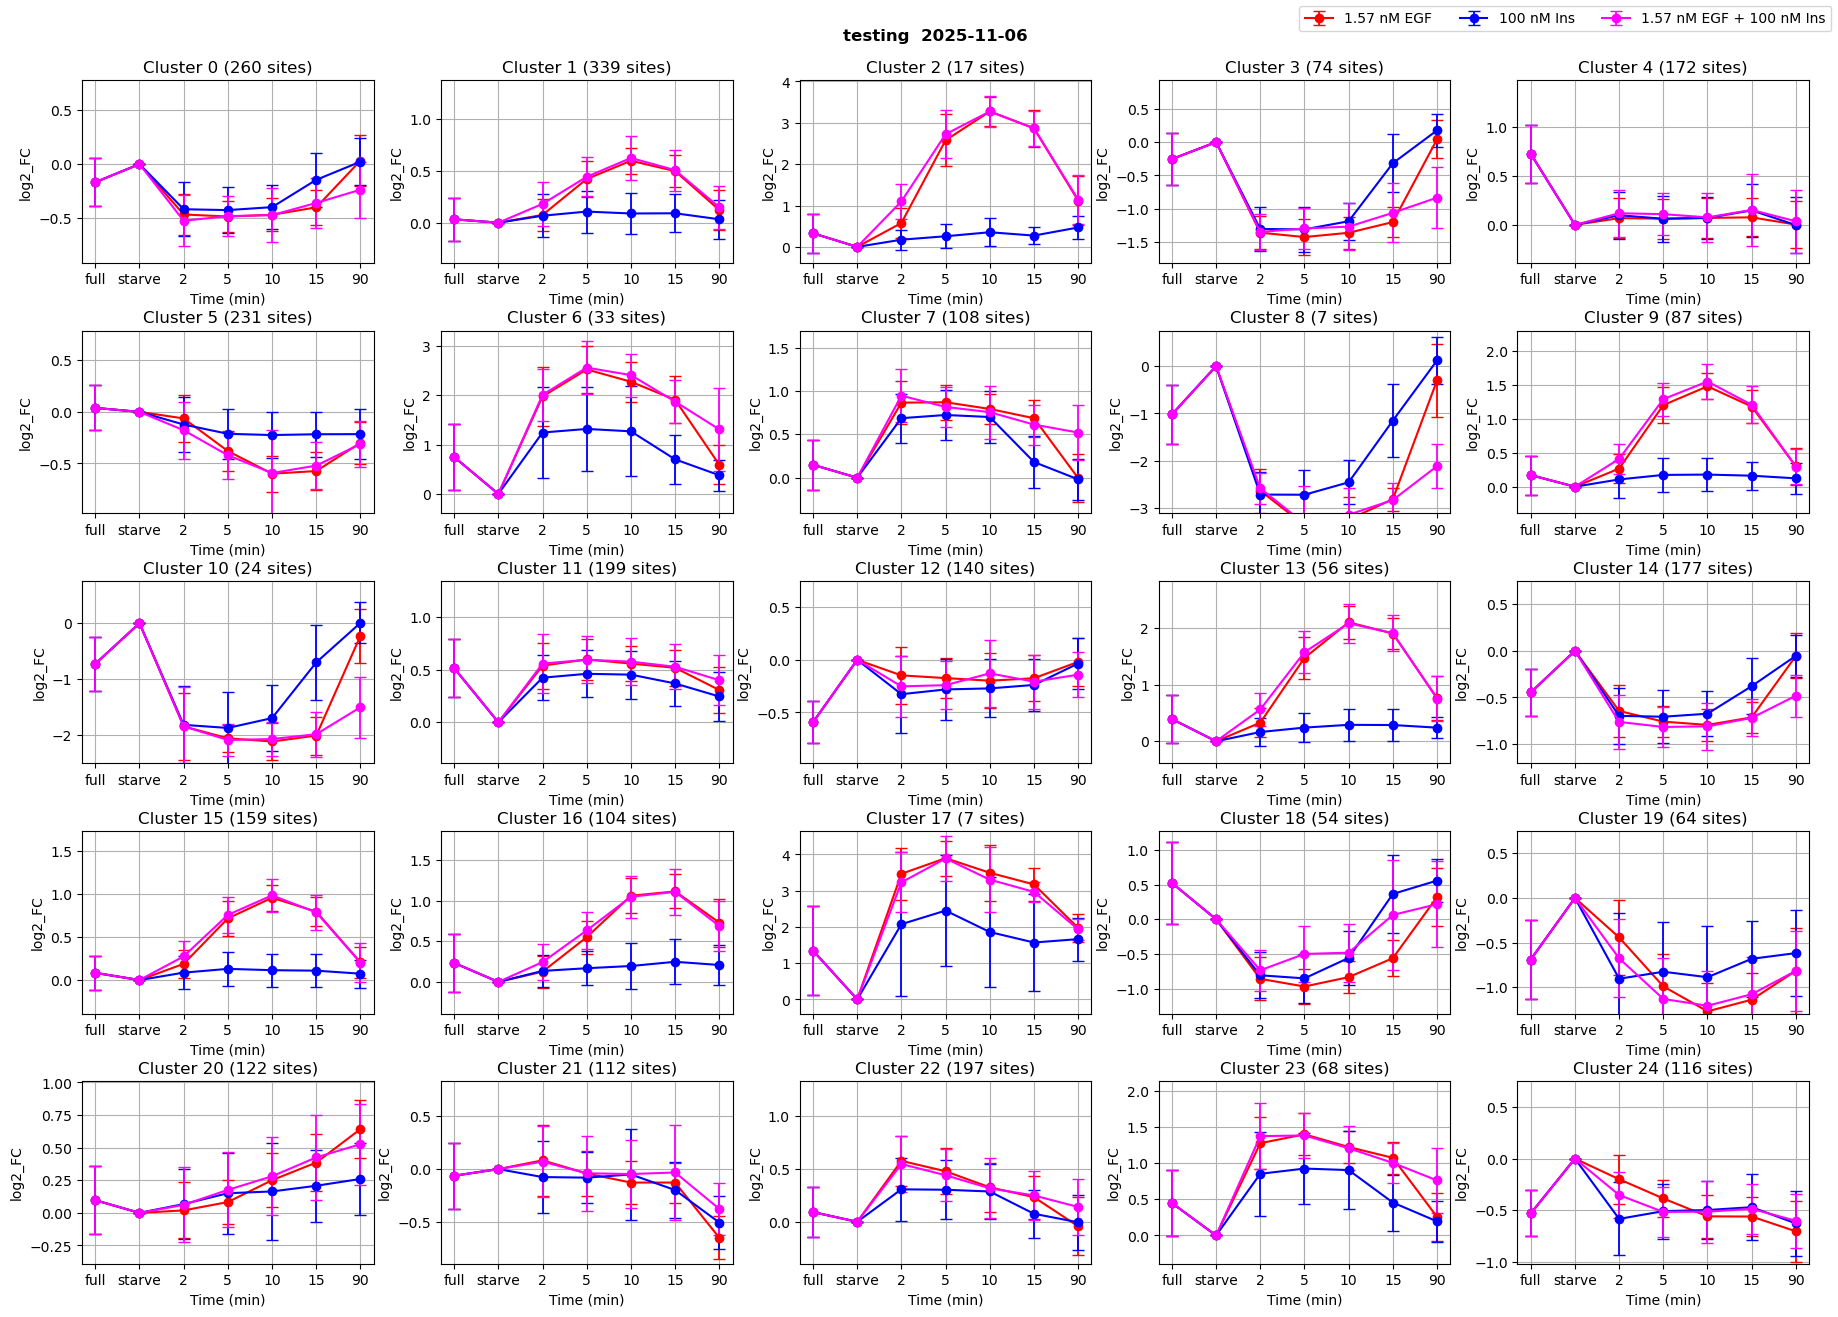

In [53]:
cluster_column = "testing"
clusters_plot(df=df_1_HEK_scaled,
              legend=['1.57 nM EGF', '100 nM Ins', '1.57 nM EGF + 100 nM Ins'],
              saving_path="",
              cluster_column = cluster_column,
              data_type = "log2_FC",
              plot_different_data = True,
              cluster_name="",
              saving_info="",
              y_lims_list=False,
              save_pdf=False,
              save_png=False,
              plot_close=False)